In [15]:
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("Maternal Health Risk Data Set.csv")

In [3]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
df.shape

(1014, 7)

In [5]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel          str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 63.8 KB


In [7]:
df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(562)

In [9]:
df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

In [10]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


There are 562 duplicate values and a minimum heart rate of 7 is too low and is considered an outlier.

In [11]:
df = df.drop_duplicates().reset_index(drop = True) # dropping the duplicate rows

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df[df["HeartRate"] >= 30].reset_index(drop = True)

<Axes: title={'center': 'HeartRate'}>

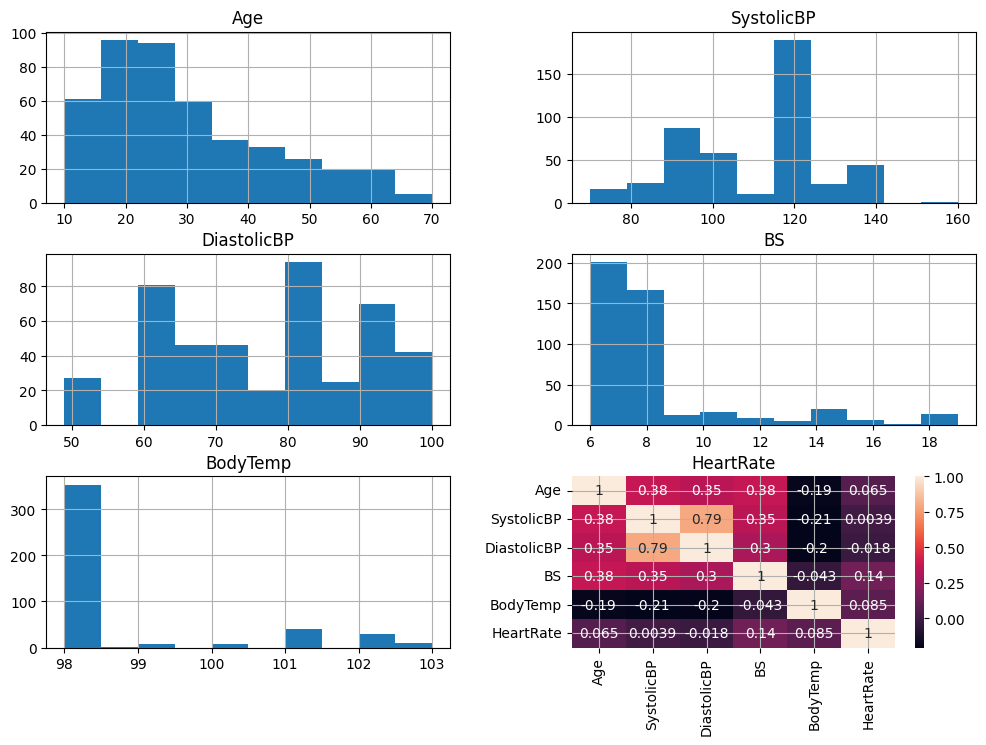

In [16]:
df.hist(figsize = (12,8))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)

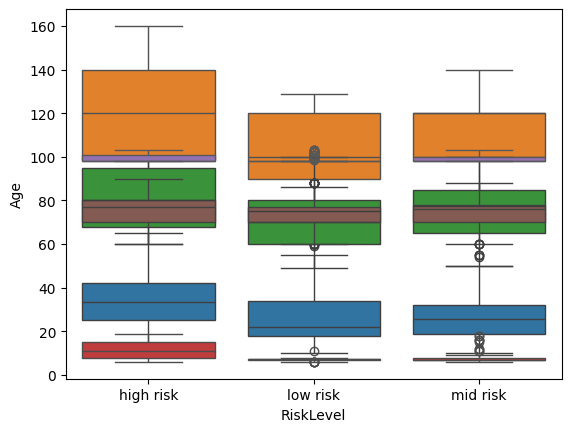

In [17]:
for col in ['Age','SystolicBP','DiastolicBP','BS','BodyTemp','HeartRate']:
    sns.boxplot(data=df, x='RiskLevel', y=col)